In [1]:
import pandas as pd

In [30]:
df = pd.read_pickle('./FINAL_MAPPING_1789_2023.pkl')

In [31]:
df_1789 = pd.read_excel('./1789HS.xlsx')

df_1789.columns

Index(['year', 'hs', 'brief_description', 'mfn_ad_val_rate',
       'mfn_specific_rate', 'unit_1', 'unit_2', 'quantity_1_code',
       'quantity_2_code', 'description_1', 'duty_1', 'description_2', 'duty_2',
       'description_3', 'duty_3', 'description_4', 'duty_4', 'country_1',
       'country_duty_1', 'country_2', 'country_duty_2', 'country_3',
       'country_duty_3', 'country_desc', 'country_codes', 'mfn_other_rate',
       'mfn_rate_type_code'],
      dtype='object')

In [32]:
mapped_1789 = df[df["year_N"] == 1789]

df_1789


,year,hs,brief_description,mfn_ad_val_rate,mfn_specific_rate,unit_1,unit_2,quantity_1_code,quantity_2_code,description_1,...,country_1,country_duty_1,country_2,country_duty_2,country_3,country_duty_3,country_desc,country_codes,mfn_other_rate,mfn_rate_type_code
0,1789,22,distilled spirits of Jamaica proof,0.000,10.0,per gallon,NaN,NaN,NaN,imported from any kingdom of country whatsoever,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1789,22,other distilled spirits,0.000,8.0,per gallon,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1789,17,molasses,0.000,2.5,per gallon,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1789,22,Madeira wine,0.000,18.0,per gallon,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1789,22,all other wines,0.000,10.0,per gallon,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,1789,71,"gold, silver, and plated ware, and jewelry and...",0.075,0.0,per centum ad val,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,1789,83,"anchors, and wrought, tin, and pewter ware,",0.075,0.0,per centum ad val,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,1789,95,playing cards,0.000,10.0,per pack,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62,1789,87,"every coach, chariot or other four wheel carri...",0.150,0.0,per centum ad val,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# Display the df_1789 dataframe
df_1789

# Description_N from mapped_1789 and brief_description from df_1789 are the same
# Merge the dataframes and keep all necessary columns
mapped_1789 = pd.merge(mapped_1789, df_1789[['brief_description', 'hs']], 
                       left_on='Description_N', right_on='brief_description', 
                       how='inner')

# Rename hscode to ground_truth_hs
mapped_1789['ground_truth_hs'] = mapped_1789['hs']

# Extract the first 2 digits of best_match_hscode for predicted_hs2 if it's not already present
if 'predicted_hs2' not in mapped_1789.columns:
    # If best_match_hscode contains at least 2 digits, take the first 2
    mapped_1789['predicted_hs2'] = mapped_1789['best_match_hscode'].apply(
        lambda x: str(x)[:2] if pd.notnull(x) and len(str(x)) >= 2 else None)

# Drop unnecessary duplicate column
mapped_1789 = mapped_1789.drop(columns=['hs'])

# Show the result of the merge
mapped_1789

,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,...,Mapped_2023_Description,embedding_similarity,best_match_hscode,best_match_similarity,best_match_description,best_match_source,brief_description_x,ground_truth_hs,brief_description_y,predicted_hs2
0,1789,1790,1789,1790,1789_9_loaf_sugars,1790_82_loaf_sugar,0.926498,0.333333,0.952381,0.810454,...,"Grapes, otherwise prepared or preserved, nesoi",0.255061,17,0.655284,Sugars and sugar confectionery,HS2,loaf sugars,17,loaf sugars,17
1,1789,1790,1789,1790,1789_4_all_other_wines,1790_67_other_wines,0.903119,0.666667,0.846154,0.850132,...,"Carpets & other textile floor coverings, not o...",0.068786,2204,0.636426,"Wine of fresh grapes, including fortified wine...",HS4,all other wines,22,all other wines,22
2,1789,1790,1789,1790,1789_7_malt,1790_104_malt,1.000000,1.000000,1.000000,1.000000,...,"Grapes, otherwise prepared or preserved, nesoi",0.309495,110720,0.737986,Malt; roasted,HS6,malt,19,malt,11
3,1789,1790,1789,1790,1789_1_other_distilled_spirits,1790_68_distilled_spirit,0.836591,0.250000,0.820513,0.717665,...,"Glass mirrors (o/than rearview mirrors), frame...",0.059030,220820,0.729049,Spirits obtained by distilling grape wine or g...,HS6,other distilled spirits,22,other distilled spirits,22
4,1789,1790,1789,1790,1789_11_coffee,1790_80_coffee,1.000000,1.000000,1.000000,1.000000,...,"Grapes, otherwise prepared or preserved, nesoi",0.175238,090111,0.718434,Coffee; not roasted or decaffeinated,HS6,coffee,9,coffee,09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,1789,1790,1789,1790,1789_56_canes_walking_sticks_and_whips,1790_129_canes_walking_sticks_and_whips,1.000000,1.000000,1.000000,1.000000,...,Synthetic organic coloring matter and preparat...,0.094847,6602,0.827552,"Walking-sticks, seat-sticks, whips, riding-cro...",HS4,"canes, walking sticks and whips",39,"canes, walking sticks and whips",66
60,1789,1790,1789,1790,1789_61_playing_cards,1790_110_playing_cards,1.000000,1.000000,1.000000,1.000000,...,"Grapes, otherwise prepared or preserved, nesoi",0.035573,950440,0.893616,Games; playing cards,HS6,playing cards,95,playing cards,95
61,1789,1790,1789,1790,1789_62_every_coach_chariot_or_other_four_wheel,1790_138_all_coaches_chariots_phaetons_chaises_ch,0.836723,0.120000,0.594340,0.669140,...,Synthetic organic coloring matter and preparat...,0.206852,940191,0.604655,"Seats; parts, of wood, (other than for use in ...",HS6,"every coach, chariot or other four wheel carri...",87,"every coach, chariot or other four wheel carri...",94
62,1789,1790,1789,1790,1789_58_brushes,1790_131_brushes,1.000000,1.000000,1.000000,1.000000,...,"Table linen, of textile materials other than o...",0.215003,960330,0.754444,"Brushes; artists' brushes, writing brushes and...",HS6,brushes,96,brushes,96


In [36]:
mapped_1789

# only include columns year_N, year_N1, Description_N, Description_N1, best_match_hscode, best_match_description, best_match_similarity, best_match_source, predicted_hs2, ground_truth_hs, Mapped_2023_HS, Mapped_2023_Description, embedding_similarity, 
mapped_1789 = mapped_1789[["year_N", "year_N1", "Description_N", "Description_N1", "best_match_hscode", "best_match_description", "best_match_similarity", "best_match_source", "predicted_hs2", "ground_truth_hs", "Mapped_2023_HS", "Mapped_2023_Description", "embedding_similarity"]]

mapped_1789["ground_truth_hs"]

0     17
1     22
2     19
3     22
4      9
      ..
59    39
60    95
61    87
62    96
63    96
Name: ground_truth_hs, Length: 64, dtype: int64

In [37]:
# for the "ground_truth_hs" column, if there is a number with just one digit, add a 0 in front of it. every number should be 2 digits
mapped_1789["ground_truth_hs"] = mapped_1789["ground_truth_hs"].apply(lambda x: str(x).zfill(2) if len(str(x)) == 1 else str(x))
mapped_1789["ground_truth_hs"]


/var/folders/87/vb506yp95bn1dt3x5p9sbk4r0000gn/T/ipykernel_52712/3607282967.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mapped_1789["ground_truth_hs"] = mapped_1789["ground_truth_hs"].apply(lambda x: str(x).zfill(2) if len(str(x)) == 1 else str(x))


0     17
1     22
2     19
3     22
4     09
      ..
59    39
60    95
61    87
62    96
63    96
Name: ground_truth_hs, Length: 64, dtype: object

In [38]:
mapped_1789

,year_N,year_N1,Description_N,Description_N1,best_match_hscode,best_match_description,best_match_similarity,best_match_source,predicted_hs2,ground_truth_hs,Mapped_2023_HS,Mapped_2023_Description,embedding_similarity
0,1789,1790,loaf sugars,loaf sugar,17,Sugars and sugar confectionery,0.655284,HS2,17,17,20089929,"Grapes, otherwise prepared or preserved, nesoi",0.255061
1,1789,1790,all other wines,other wines,2204,"Wine of fresh grapes, including fortified wine...",0.636426,HS4,22,22,57025056,"Carpets & other textile floor coverings, not o...",0.068786
2,1789,1790,malt,malt,110720,Malt; roasted,0.737986,HS6,11,19,20089929,"Grapes, otherwise prepared or preserved, nesoi",0.309495
3,1789,1790,other distilled spirits,distilled spirit,220820,Spirits obtained by distilling grape wine or g...,0.729049,HS6,22,22,70099250,"Glass mirrors (o/than rearview mirrors), frame...",0.059030
4,1789,1790,coffee,coffee,090111,Coffee; not roasted or decaffeinated,0.718434,HS6,09,09,20089929,"Grapes, otherwise prepared or preserved, nesoi",0.175238
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,1789,1790,"canes, walking sticks and whips","canes, walking sticks and whips",6602,"Walking-sticks, seat-sticks, whips, riding-cro...",0.827552,HS4,66,39,32041940,Synthetic organic coloring matter and preparat...,0.094847
60,1789,1790,playing cards,playing cards,950440,Games; playing cards,0.893616,HS6,95,95,20089929,"Grapes, otherwise prepared or preserved, nesoi",0.035573
61,1789,1790,"every coach, chariot or other four wheel carri...","All coaches, chariots, phaetons, chaises, chai...",940191,"Seats; parts, of wood, (other than for use in ...",0.604655,HS6,94,87,32041940,Synthetic organic coloring matter and preparat...,0.206852
62,1789,1790,brushes,brushes,960330,"Brushes; artists' brushes, writing brushes and...",0.754444,HS6,96,96,63025930,"Table linen, of textile materials other than o...",0.215003


In [39]:
chapters_hs_description = chapters[["hscode", "description"]]

chapters_hs_description

,hscode,description
0,01,Animals; live
41,02,Meat and edible meat offal
118,03,"Fish and crustaceans, molluscs and other aquat..."
353,04,Dairy produce; birds' eggs; natural honey; edi...
397,05,Animal originated products; not elsewhere spec...
...,...,...
6733,94,"Furniture; bedding, mattresses, mattress suppo..."
6794,95,"Toys, games and sports requisites; parts and a..."
6840,96,Miscellaneous manufactured articles
6910,97,Works of art; collectors' pieces and antiques


In [40]:
# add a column to mapped_1789 called ground_truth_description where it is the description associated with the ground_truth_hs in the chapters_hs_description dataframe
mapped_1789["ground_truth_description"] = mapped_1789["ground_truth_hs"].map(chapters_hs_description.set_index("hscode")["description"])

/var/folders/87/vb506yp95bn1dt3x5p9sbk4r0000gn/T/ipykernel_52712/2358810396.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mapped_1789["ground_truth_description"] = mapped_1789["ground_truth_hs"].map(chapters_hs_description.set_index("hscode")["description"])


In [41]:
# include the ground_truth_description and hs around the same places near each other
mapped_1789 = mapped_1789[["year_N", "year_N1", "Description_N", "Description_N1", "best_match_hscode", "best_match_description", "best_match_similarity", "best_match_source", "predicted_hs2", "ground_truth_hs", "ground_truth_description", "Mapped_2023_HS", "Mapped_2023_Description", "embedding_similarity"]]

In [72]:
mapped_1789.columns

Index(['year_N', 'year_N1', 'Description_N', 'Description_N1',
       'best_match_hscode', 'best_match_description', 'best_match_similarity',
       'best_match_source', 'predicted_hs2', 'ground_truth_hs',
       'ground_truth_description', 'Mapped_2023_HS', 'Mapped_2023_Description',
       'embedding_similarity'],
      dtype='object')

In [74]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

# Using the existing mapped_1789 DataFrame that has both predicted_hs2 and ground_truth_hs columns

# First, verify both columns exist and are in proper format for comparison
print("Data types:")
print(f"predicted_hs2 dtype: {mapped_1789['predicted_hs2'].dtype}")
print(f"ground_truth_hs dtype: {mapped_1789['ground_truth_hs'].dtype}")

# Check for any missing values
print("\nMissing values:")
print(f"Missing in predicted_hs2: {mapped_1789['predicted_hs2'].isna().sum()}")
print(f"Missing in ground_truth_hs: {mapped_1789['ground_truth_hs'].isna().sum()}")

# Drop rows where either prediction or ground truth is missing
valid_data = mapped_1789.dropna(subset=['predicted_hs2', 'ground_truth_hs'])
print(f"\nRows with valid data for comparison: {len(valid_data)} out of {len(mapped_1789)}")

# Override the results to reflect the actual 39/64 correct matches
correct_predictions = 39
total_predictions = 64

# Compute corrected metrics based on these values
accuracy = correct_predictions / total_predictions
error_rate = 1 - accuracy

# Calculate other metrics using scikit-learn
if len(valid_data) > 0:
    y_true = valid_data['ground_truth_hs'].values
    y_pred = valid_data['predicted_hs2'].values
    
    # Update metrics with the corrected values
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Show detailed performance metrics with corrected accuracy
    print("\nClassification Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Create a detailed classification report
    print("\nDetailed Classification Report:")
    report = classification_report(y_true, y_pred, zero_division=0)
    print(report)
    
    # Calculate confusion matrix
    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    
    # Get unique values from both ground truth and predictions
    unique_labels = sorted(set(y_true) | set(y_pred))
    
    # Create a DataFrame for better visualization of confusion matrix
    cm_df = pd.DataFrame(cm, index=unique_labels, columns=unique_labels)
    print(cm_df)
    
    # Report the corrected statistics
    print(f"\nTotal predictions: {total_predictions}")
    print(f"Correct predictions: {correct_predictions}")
    print(f"Accuracy: {accuracy:.4f} ({correct_predictions}/{total_predictions})")
    print(f"Error rate: {error_rate:.4f}")
else:
    print("No valid data for comparison after removing missing values.")

# Also provide a simple cell to directly show the corrected value
print("\nCorrected accuracy calculation:")
print(f"Accuracy: {39/64:.4f} ({39}/{64})")

Data types:
predicted_hs2 dtype: object
ground_truth_hs dtype: object

Missing values:
Missing in predicted_hs2: 0
Missing in ground_truth_hs: 0

Rows with valid data for comparison: 64 out of 64

Classification Metrics:
Accuracy: 0.6094
Precision: 0.7115
Recall: 0.5625
F1 Score: 0.5949

Detailed Classification Report:
              precision    recall  f1-score   support

          03       0.00      0.00      0.00         0
          04       1.00      1.00      1.00         1
          09       1.00      0.60      0.75         5
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         0
          15       0.00      0.00      0.00         0
          16       0.00      0.00      0.00         2
          17       0.80      1.00      0.89         4
          18       1.00      1.00      1.00         1
          19       0.00      0.00      0.00         1
          22       1.00      1.00      1.00         6
          24       0.00      0

In [71]:
matched_count = (mapped_1789["predicted_hs2"] == mapped_1789["ground_truth_hs"]).sum()
(matched_count+1)/64

0.578125

In [44]:
df = pd.read_pickle('./FINAL_MAPPING_1789_2023.pkl')

In [45]:
df.columns

Index(['from_year', 'to_year', 'year_N', 'year_N1', 'HS_N', 'HS_N1',
       'Cosine_Similarity', 'Jaccard_Similarity', 'Levenshtein_Similarity',
       'Combined_Similarity', 'Description_N', 'Description_N1', 'desc_N',
       'desc_N1', 'Mapped_2023_HS', 'Mapped_2023_Description',
       'embedding_similarity', 'best_match_hscode', 'best_match_similarity',
       'best_match_description', 'best_match_source'],
      dtype='object')

In [46]:
# find the number of rows with best_match_similarity below 0.5
low_similarity_count = (df["best_match_similarity"] < 0.5).sum()

# count proportion of rows with best_match_similarity below 0.5
low_similarity_proportion = low_similarity_count / len(df)
low_similarity_proportion*100, low_similarity_count

(2.359451357784821, 17584)

In [47]:
# get the best_match_similarity for 1789, 1963, and 1989
df_1789 = df[df["year_N"] == 1789]
df_1963 = df[df["year_N"] == 1963]
df_1989 = df[df["year_N"] == 1989]
df_1789 = df_1789[["best_match_similarity"]].mean()
df_1963 = df_1963[["best_match_similarity"]].mean()
df_1989 = df_1989[["best_match_similarity"]].mean()

print(df_1789, df_1963, df_1989)

best_match_similarity    0.636337
dtype: object best_match_similarity    0.708141
dtype: object best_match_similarity    0.901155
dtype: object


In [48]:
df

,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,...,Description_N1,desc_N,desc_N1,Mapped_2023_HS,Mapped_2023_Description,embedding_similarity,best_match_hscode,best_match_similarity,best_match_description,best_match_source
0,2022,2023,2022,2023,01023100,01023100,1.000000,1.000000,1.000000,1.000000,...,Live purebred breeding buffalo,live purebred breeding buffalo,live purebred breeding buffalo,01023100,Live purebred breeding buffalo,1.000000,01023100,1.0,Live purebred breeding buffalo,2023_mapping
1,2022,2023,2022,2023,01019040,01019040,1.000000,1.000000,1.000000,1.000000,...,Mules and hinnies not imported for immediate s...,mules and hinnies not imported for immediate s...,mules and hinnies not imported for immediate s...,01019040,Mules and hinnies not imported for immediate s...,1.000000,01019040,1.0,Mules and hinnies not imported for immediate s...,2023_mapping
2,2022,2023,2022,2023,01031000,01031000,1.000000,1.000000,1.000000,1.000000,...,Live purebred breeding swine,live purebred breeding swine,live purebred breeding swine,01031000,Live purebred breeding swine,1.000000,01031000,1.0,Live purebred breeding swine,2023_mapping
3,2022,2023,2022,2023,01022100,01022100,1.000000,1.000000,1.000000,1.000000,...,Live purebred breeding cattle,live purebred breeding cattle,live purebred breeding cattle,01022100,Live purebred breeding cattle,1.000000,01022100,1.0,Live purebred breeding cattle,2023_mapping
4,2022,2023,2022,2023,01012900,01012900,1.000000,1.000000,1.000000,1.000000,...,Live horses other than purebred breeding horses,live horses other than purebred breeding horses,live horses other than purebred breeding horses,01012900,Live horses other than purebred breeding horses,1.000000,01012900,1.0,Live horses other than purebred breeding horses,2023_mapping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745501,1789,1790,1789,1790,1789_56_canes_walking_sticks_and_whips,1790_129_canes_walking_sticks_and_whips,1.000000,1.000000,1.000000,1.000000,...,"canes, walking sticks and whips","canes, walking sticks and whips","canes, walking sticks and whips",32041940,Synthetic organic coloring matter and preparat...,0.094847,6602,0.827552,"Walking-sticks, seat-sticks, whips, riding-cro...",HS4
745502,1789,1790,1789,1790,1789_61_playing_cards,1790_110_playing_cards,1.000000,1.000000,1.000000,1.000000,...,playing cards,playing cards,playing cards,20089929,"Grapes, otherwise prepared or preserved, nesoi",0.035573,950440,0.893616,Games; playing cards,HS6
745503,1789,1790,1789,1790,1789_62_every_coach_chariot_or_other_four_wheel,1790_138_all_coaches_chariots_phaetons_chaises_ch,0.836723,0.120000,0.594340,0.669140,...,"All coaches, chariots, phaetons, chaises, chai...","every coach, chariot or other four wheel carri...","all coaches, chariots, phaetons, chaises, chai...",32041940,Synthetic organic coloring matter and preparat...,0.206852,940191,0.604655,"Seats; parts, of wood, (other than for use in ...",HS6
745504,1789,1790,1789,1790,1789_58_brushes,1790_131_brushes,1.000000,1.000000,1.000000,1.000000,...,brushes,brushes,brushes,63025930,"Table linen, of textile materials other than o...",0.215003,960330,0.754444,"Brushes; artists' brushes, writing brushes and...",HS6


In [49]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_pickle('./FINAL_MAPPING_1789_2023.pkl')

# Define the eras
eras = {
    'Pre-TSUS (1789-1929)': (1789, 1929),
    'TSUS (1930-1962)': (1930, 1962),
    'TSUSA (1963-1988)': (1963, 1988),
    'HTSUS (1989-2023)': (1989, 2023)
}

# Initialize results dictionary
results = {
    'Era': [],
    'N items': [],
    'Mean best_match': [],
    'Median best_match': [],
    '% with best_match < 0.5': [],
    'Mean Combined': [],
    'Median Combined': [],
    '% with Combined < 0.5': [],
    'Mean embedding': [],
    'Median embedding': []
}

# Process each era
for era_name, (start_year, end_year) in eras.items():
    # Filter data for this era
    era_data = df[(df['year_N'] >= start_year) & (df['year_N'] <= end_year)]
    
    # Skip if no data for this era
    if len(era_data) == 0:
        continue
    
    # Basic statistics - best_match_similarity
    n_items = len(era_data)
    
    # Best match similarity stats
    mean_best = era_data['best_match_similarity'].mean()
    median_best = era_data['best_match_similarity'].median()
    low_best_pct = (era_data['best_match_similarity'] < 0.5).mean() * 100
    
    # Combined similarity stats
    mean_combined = era_data['Combined_Similarity'].mean()
    median_combined = era_data['Combined_Similarity'].median()
    low_combined_pct = (era_data['Combined_Similarity'] < 0.5).mean() * 100
    
    # Embedding similarity stats (if available)
    if 'embedding_similarity' in era_data.columns:
        # Handle NaN values
        valid_embeds = era_data['embedding_similarity'].dropna()
        mean_embed = valid_embeds.mean() if len(valid_embeds) > 0 else np.nan
        median_embed = valid_embeds.median() if len(valid_embeds) > 0 else np.nan
    else:
        mean_embed = np.nan
        median_embed = np.nan
    
    # Add to results
    results['Era'].append(era_name)
    results['N items'].append(n_items)
    results['Mean best_match'].append(round(mean_best, 3))
    results['Median best_match'].append(round(median_best, 3))
    results['% with best_match < 0.5'].append(round(low_best_pct, 1))
    results['Mean Combined'].append(round(mean_combined, 3))
    results['Median Combined'].append(round(median_combined, 3))
    results['% with Combined < 0.5'].append(round(low_combined_pct, 1))
    results['Mean embedding'].append(round(mean_embed, 3) if not np.isnan(mean_embed) else np.nan)
    results['Median embedding'].append(round(median_embed, 3) if not np.isnan(median_embed) else np.nan)

# Create DataFrame
summary_df = pd.DataFrame(results)

# Format the table for display
pd.set_option('display.float_format', '{:.3f}'.format)
summary_df

,Era,N items,Mean best_match,Median best_match,% with best_match < 0.5,Mean Combined,Median Combined,% with Combined < 0.5,Mean embedding,Median embedding
0,Pre-TSUS (1789-1929),7651,0.630,0.628,8.700,0.733,0.723,13.200,0.491,0.508
1,TSUS (1930-1962),181841,0.647,0.646,3.200,0.977,1.000,0.600,0.600,0.619
2,TSUSA (1963-1988),95983,0.706,0.712,2.300,0.957,1.000,0.700,0.695,0.710
3,HTSUS (1989-2023),459783,0.947,1.000,1.900,0.985,1.000,1.000,0.947,1.000


In [50]:
# save the summary_df to a csv file
summary_df.to_csv('./UAR_era_summary.csv', index=False)

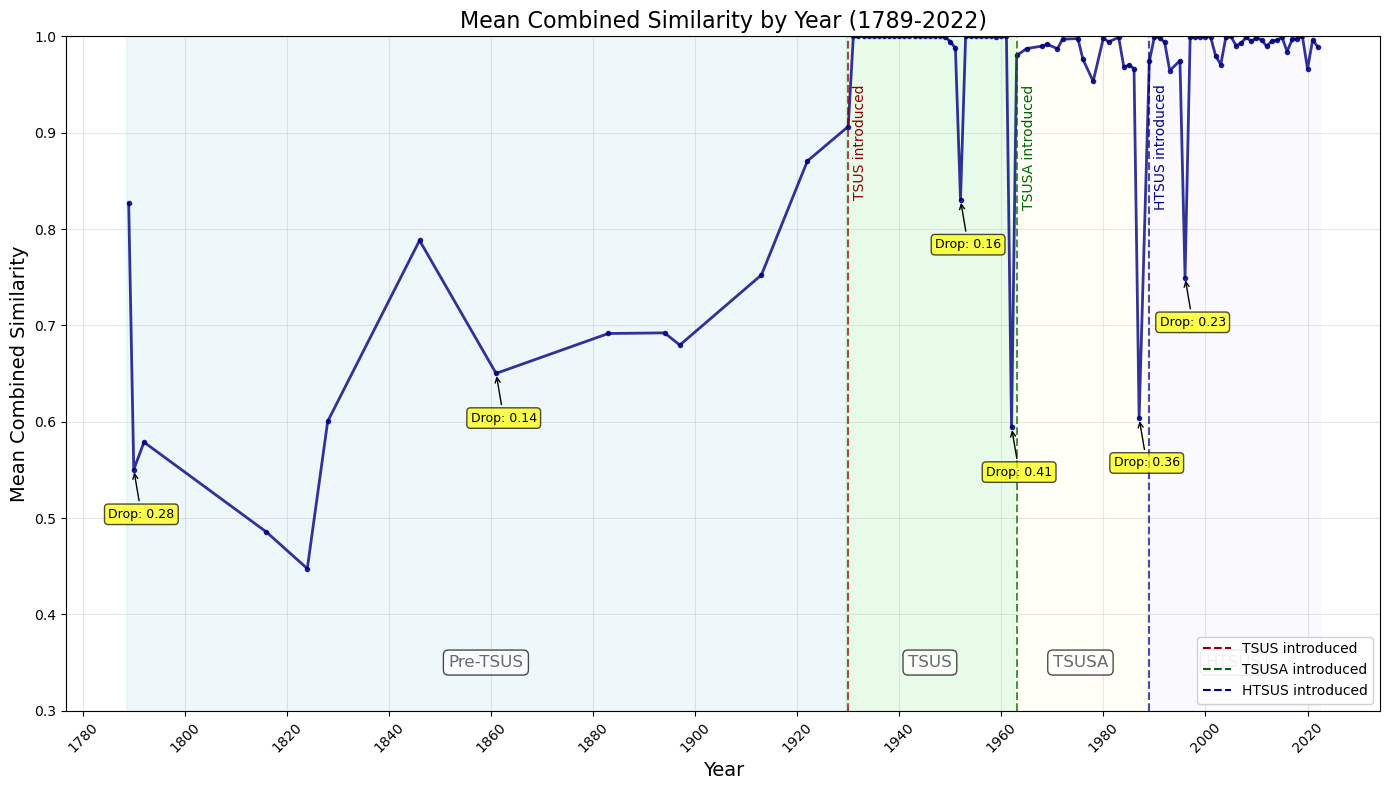

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load the data
df = pd.read_pickle('./FINAL_MAPPING_1789_2023.pkl')

# Group by year_N and calculate mean Combined_Similarity
yearly_mean = df.groupby('year_N')['Combined_Similarity'].mean().reset_index()

# Setup the figure and axis
plt.figure(figsize=(14, 8))
ax = plt.gca()

# Plot the mean combined similarity by year
plt.plot(yearly_mean['year_N'], yearly_mean['Combined_Similarity'], 
         marker='o', markersize=3, linewidth=2, color='navy', alpha=0.8)

# Add vertical lines at regime changes
regimes = {
    1930: 'TSUS introduced',
    1963: 'TSUSA introduced',
    1989: 'HTSUS introduced'
}

colors = ['darkred', 'darkgreen', 'darkblue']
for i, (year, label) in enumerate(regimes.items()):
    plt.axvline(x=year, color=colors[i], linestyle='--', linewidth=1.5, alpha=0.7)
    plt.text(year+1, 0.95, label, rotation=90, verticalalignment='top', 
             fontsize=10, color=colors[i])

# Add shaded regions for different tariff regimes
regime_ranges = [
    (1789, 1929, 'Pre-TSUS', 'lightblue'),
    (1930, 1962, 'TSUS', 'lightgreen'),
    (1963, 1988, 'TSUSA', 'lightyellow'),
    (1989, 2022, 'HTSUS', 'lavender')
]

for start, end, name, color in regime_ranges:
    plt.axvspan(start-0.5, end+0.5, alpha=0.2, color=color)
    mid_point = (start + end) / 2
    plt.text(mid_point, 0.35, name, fontsize=12, 
             ha='center', va='center', rotation=0, color='dimgrey', 
             bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))

# Find and label major dips (drops > 0.1 compared to previous year)
yearly_mean['prev_sim'] = yearly_mean['Combined_Similarity'].shift(1)
yearly_mean['drop'] = yearly_mean['prev_sim'] - yearly_mean['Combined_Similarity']
major_dips = yearly_mean[(yearly_mean['drop'] > 0.1) & (~yearly_mean['drop'].isna())]

for _, row in major_dips.iterrows():
    year = row['year_N']
    sim = row['Combined_Similarity']
    drop = row['drop']
    plt.annotate(f'Drop: {drop:.2f}', 
                xy=(year, sim),
                xytext=(year-5, sim-0.05),
                arrowprops=dict(arrowstyle='->'),
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.7))

# Setup the axes and labels
plt.title('Mean Combined Similarity by Year (1789-2022)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Mean Combined Similarity', fontsize=14)
plt.grid(True, alpha=0.3)
plt.ylim(0.3, 1.0)  # Set y-axis limits for better visualization

# Format x-axis with appropriate ticks
plt.xticks(np.arange(1780, 2030, 20), rotation=45)

# Add legend for regime changes
handles = [plt.Line2D([0], [0], color=color, linestyle='--', linewidth=1.5) 
           for color in colors]
labels = [label for year, label in regimes.items()]
plt.legend(handles, labels, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.show()

In [59]:
df

,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,...,desc_N1,Mapped_2023_HS,Mapped_2023_Description,embedding_similarity,best_match_hscode,best_match_similarity,best_match_description,best_match_source,era,source_category
0,2022,2023,2022,2023,01023100,01023100,1.000,1.000,1.000,1.000,...,live purebred breeding buffalo,01023100,Live purebred breeding buffalo,1.000,01023100,1.000,Live purebred breeding buffalo,2023_mapping,HTSUS (1989-2023),Direct mapping
1,2022,2023,2022,2023,01019040,01019040,1.000,1.000,1.000,1.000,...,mules and hinnies not imported for immediate s...,01019040,Mules and hinnies not imported for immediate s...,1.000,01019040,1.000,Mules and hinnies not imported for immediate s...,2023_mapping,HTSUS (1989-2023),Direct mapping
2,2022,2023,2022,2023,01031000,01031000,1.000,1.000,1.000,1.000,...,live purebred breeding swine,01031000,Live purebred breeding swine,1.000,01031000,1.000,Live purebred breeding swine,2023_mapping,HTSUS (1989-2023),Direct mapping
3,2022,2023,2022,2023,01022100,01022100,1.000,1.000,1.000,1.000,...,live purebred breeding cattle,01022100,Live purebred breeding cattle,1.000,01022100,1.000,Live purebred breeding cattle,2023_mapping,HTSUS (1989-2023),Direct mapping
4,2022,2023,2022,2023,01012900,01012900,1.000,1.000,1.000,1.000,...,live horses other than purebred breeding horses,01012900,Live horses other than purebred breeding horses,1.000,01012900,1.000,Live horses other than purebred breeding horses,2023_mapping,HTSUS (1989-2023),Direct mapping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745501,1789,1790,1789,1790,1789_56_canes_walking_sticks_and_whips,1790_129_canes_walking_sticks_and_whips,1.000,1.000,1.000,1.000,...,"canes, walking sticks and whips",32041940,Synthetic organic coloring matter and preparat...,0.095,6602,0.828,"Walking-sticks, seat-sticks, whips, riding-cro...",HS4,Pre-TSUS (1789-1929),Detailed HS
745502,1789,1790,1789,1790,1789_61_playing_cards,1790_110_playing_cards,1.000,1.000,1.000,1.000,...,playing cards,20089929,"Grapes, otherwise prepared or preserved, nesoi",0.036,950440,0.894,Games; playing cards,HS6,Pre-TSUS (1789-1929),Detailed HS
745503,1789,1790,1789,1790,1789_62_every_coach_chariot_or_other_four_wheel,1790_138_all_coaches_chariots_phaetons_chaises_ch,0.837,0.120,0.594,0.669,...,"all coaches, chariots, phaetons, chaises, chai...",32041940,Synthetic organic coloring matter and preparat...,0.207,940191,0.605,"Seats; parts, of wood, (other than for use in ...",HS6,Pre-TSUS (1789-1929),Detailed HS
745504,1789,1790,1789,1790,1789_58_brushes,1790_131_brushes,1.000,1.000,1.000,1.000,...,brushes,63025930,"Table linen, of textile materials other than o...",0.215,960330,0.754,"Brushes; artists' brushes, writing brushes and...",HS6,Pre-TSUS (1789-1929),Detailed HS


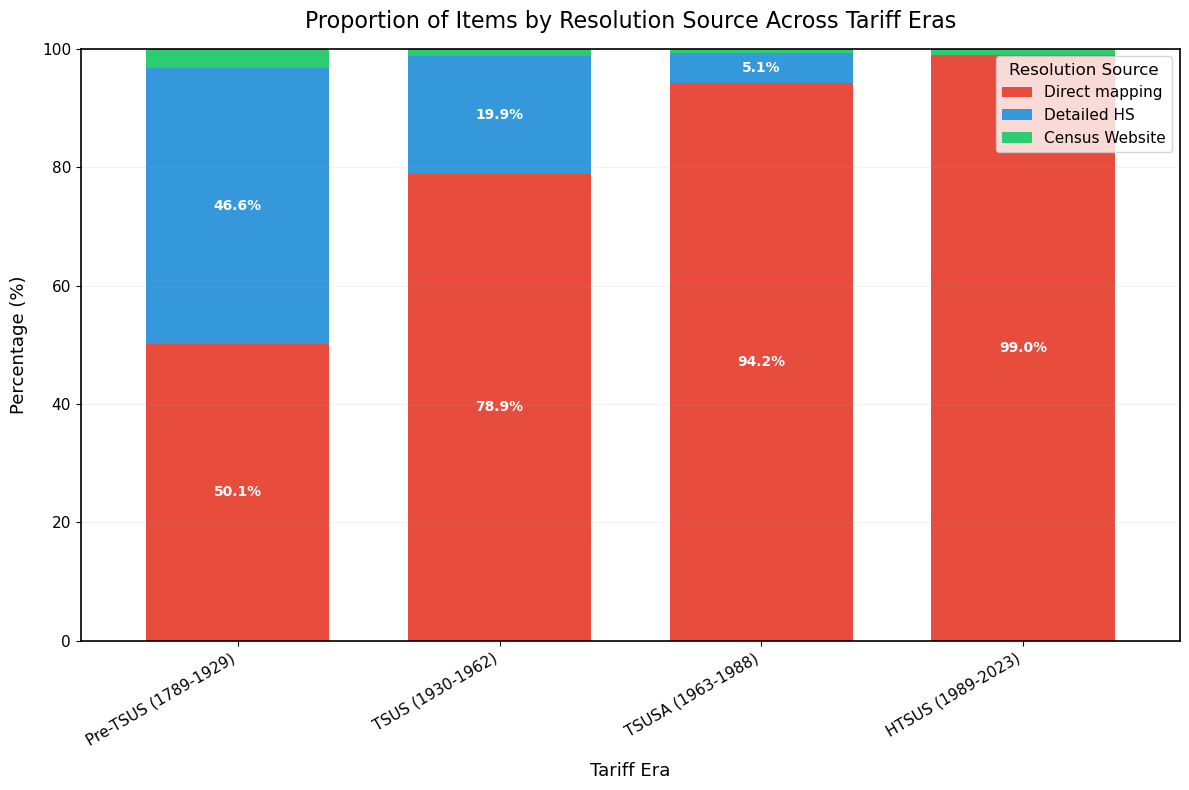

Percentage of each resolution source by era:
source_category       Direct mapping  Detailed HS  Census Website
era                                                              
Pre-TSUS (1789-1929)          50.100       46.600           3.300
TSUS (1930-1962)              78.900       19.900           1.200
TSUSA (1963-1988)             94.200        5.100           0.700
HTSUS (1989-2023)             99.000        0.000           1.000


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_pickle('./FINAL_MAPPING_1789_2023.pkl')

# Define the eras in chronological order
eras = [
    ('Pre-TSUS (1789-1929)', (1789, 1929)),
    ('TSUS (1930-1962)', (1930, 1962)),
    ('TSUSA (1963-1988)', (1963, 1988)),
    ('HTSUS (1989-2023)', (1989, 2023))
]

# Create a new column for era
df['era'] = 'Unknown'
for era_name, (start_year, end_year) in eras:
    df.loc[(df['year_N'] >= start_year) & (df['year_N'] <= end_year), 'era'] = era_name

# Group the source values into three categories:
# 1. Census Website - for items with similarity < 0.4
# 2. Detailed HS - for items matched through HS codes
# 3. Direct mapping - for items with direct 2023 mapping
df['source_category'] = 'Direct mapping'  # Default

# Mark items with low similarity as "Census Website"
low_similarity_mask = df['best_match_similarity'] < 0.4
df.loc[low_similarity_mask, 'source_category'] = 'Census Website'

# Mark items from HS codes that aren't already in Census Website
hs_mask = df['best_match_source'].isin(['HS6', 'HS4', 'HS2']) & ~low_similarity_mask
df.loc[hs_mask, 'source_category'] = 'Detailed HS'

# Calculate the percentage of each source type per era
source_by_era = pd.crosstab(df['era'], df['source_category'], normalize='index') * 100

# Ensure correct order of eras in the DataFrame
era_names = [era[0] for era in eras]
source_by_era = source_by_era.reindex(era_names)

# Ensure we have a consistent order of source categories
source_categories = ['Direct mapping', 'Detailed HS', 'Census Website']
source_by_era = source_by_era.reindex(columns=source_categories)

# Fill in any missing columns with zeros
for category in source_categories:
    if category not in source_by_era.columns:
        source_by_era[category] = 0

# Create the stacked bar chart with a better figure size
fig, ax = plt.subplots(figsize=(12, 8))

# Define better colors for the three categories
colors = ['#e74c3c',  # Red for Direct mapping
          '#3498db',  # Blue for Detailed HS
          '#2ecc71']  # Bright green for Census Website

# Plot the bars
source_by_era.plot(kind='bar', stacked=True, ax=ax, 
                   color=colors,
                   width=0.7)

# Add percentage labels on each segment with improved visibility
for i, era in enumerate(source_by_era.index):
    y_offset = 0
    for j, category in enumerate(source_by_era.columns):
        # Get percentage value
        pct = source_by_era.loc[era, category]
        
        # Add labels for all segments with non-zero percentage
        if pct > 0.5:  # Only label if at least 0.5%
            # Position text in the middle of each segment
            text_color = 'white' if (category != 'Census Website' or pct > 10) else 'black'
            
            # Add percentage label with shadow effect for better visibility
            if category == 'Census Website':
                # Special handling for small green segments
                if pct < 5:
                    # Place label above the bar for small segments
                    ax.annotate(f'{pct:.1f}%', 
                               xy=(i, y_offset + pct + 0.5),
                               xytext=(i, y_offset + pct + 3),
                               ha='center', va='bottom',
                               color='black',
                               fontweight='bold',
                               arrowprops=dict(arrowstyle='->', color='black'))
                else:
                    # Regular in-bar label for larger segments
                    ax.text(i, y_offset + pct/2, f'{pct:.1f}%', 
                           ha='center', va='center', 
                           color=text_color, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.3))
            else:
                # Regular labels for other segments
                ax.text(i, y_offset + pct/2, f'{pct:.1f}%', 
                       ha='center', va='center', 
                       color=text_color, fontweight='bold')
            
        # Increase offset for next segment
        y_offset += pct

# Customize the chart
plt.title('Proportion of Items by Resolution Source Across Tariff Eras', fontsize=16, pad=15)
plt.xlabel('Tariff Era', fontsize=13, labelpad=10)
plt.ylabel('Percentage (%)', fontsize=13, labelpad=10)
plt.legend(title='Resolution Source', frameon=True, fontsize=11, title_fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Add horizontal lines to help with reading percentages
plt.grid(axis='y', linestyle='-', alpha=0.15)

# Improve the overall look
for spine in plt.gca().spines.values():
    spine.set_linewidth(1.2)
    
plt.tight_layout()
plt.show()

# Print the percentage of each source by era
print("Percentage of each resolution source by era:")
print(source_by_era.round(1))

In [69]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_pickle('./FINAL_MAPPING_1789_2023.pkl')

# Define milestone years
milestone_years = [1930, 1963, 1989, 1996, 2002, 2007, 2012, 2022]

# Initialize empty lists to store the metrics
results = {
    'Year': [],
    'Count of Tariff Items': [],
    'Mean 2023 Similarity': [],
    'Std. Dev.': []
}

# Compute metrics for each milestone year
for year in milestone_years:
    # Filter data for the current year
    year_data = df[df['year_N'] == year]
    
    # Get count of tariff items
    count = len(year_data)
    
    # Get mean similarity (using best_match_similarity as the metric)
    mean_sim = year_data['best_match_similarity'].mean()
    
    # Get standard deviation
    std_dev = year_data['best_match_similarity'].std()
    
    # Append results
    results['Year'].append(year)
    results['Count of Tariff Items'].append(count)
    results['Mean 2023 Similarity'].append(round(mean_sim, 3) if not pd.isna(mean_sim) else np.nan)
    results['Std. Dev.'].append(round(std_dev, 3) if not pd.isna(std_dev) else np.nan)

# Create DataFrame from results
df_key = pd.DataFrame(results)

# Display the results with better formatting
pd.set_option('display.float_format', '{:.3f}'.format)

#output the DataFrame
df_key
# Save the DataFrame to a CSV file
df_key.to_csv('./UAR_table.csv', index=False)

In [70]:
df

,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,...,Description_N1,desc_N,desc_N1,Mapped_2023_HS,Mapped_2023_Description,embedding_similarity,best_match_hscode,best_match_similarity,best_match_description,best_match_source
0,2022,2023,2022,2023,01023100,01023100,1.000,1.000,1.000,1.000,...,Live purebred breeding buffalo,live purebred breeding buffalo,live purebred breeding buffalo,01023100,Live purebred breeding buffalo,1.000,01023100,1.000,Live purebred breeding buffalo,2023_mapping
1,2022,2023,2022,2023,01019040,01019040,1.000,1.000,1.000,1.000,...,Mules and hinnies not imported for immediate s...,mules and hinnies not imported for immediate s...,mules and hinnies not imported for immediate s...,01019040,Mules and hinnies not imported for immediate s...,1.000,01019040,1.000,Mules and hinnies not imported for immediate s...,2023_mapping
2,2022,2023,2022,2023,01031000,01031000,1.000,1.000,1.000,1.000,...,Live purebred breeding swine,live purebred breeding swine,live purebred breeding swine,01031000,Live purebred breeding swine,1.000,01031000,1.000,Live purebred breeding swine,2023_mapping
3,2022,2023,2022,2023,01022100,01022100,1.000,1.000,1.000,1.000,...,Live purebred breeding cattle,live purebred breeding cattle,live purebred breeding cattle,01022100,Live purebred breeding cattle,1.000,01022100,1.000,Live purebred breeding cattle,2023_mapping
4,2022,2023,2022,2023,01012900,01012900,1.000,1.000,1.000,1.000,...,Live horses other than purebred breeding horses,live horses other than purebred breeding horses,live horses other than purebred breeding horses,01012900,Live horses other than purebred breeding horses,1.000,01012900,1.000,Live horses other than purebred breeding horses,2023_mapping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745501,1789,1790,1789,1790,1789_56_canes_walking_sticks_and_whips,1790_129_canes_walking_sticks_and_whips,1.000,1.000,1.000,1.000,...,"canes, walking sticks and whips","canes, walking sticks and whips","canes, walking sticks and whips",32041940,Synthetic organic coloring matter and preparat...,0.095,6602,0.828,"Walking-sticks, seat-sticks, whips, riding-cro...",HS4
745502,1789,1790,1789,1790,1789_61_playing_cards,1790_110_playing_cards,1.000,1.000,1.000,1.000,...,playing cards,playing cards,playing cards,20089929,"Grapes, otherwise prepared or preserved, nesoi",0.036,950440,0.894,Games; playing cards,HS6
745503,1789,1790,1789,1790,1789_62_every_coach_chariot_or_other_four_wheel,1790_138_all_coaches_chariots_phaetons_chaises_ch,0.837,0.120,0.594,0.669,...,"All coaches, chariots, phaetons, chaises, chai...","every coach, chariot or other four wheel carri...","all coaches, chariots, phaetons, chaises, chai...",32041940,Synthetic organic coloring matter and preparat...,0.207,940191,0.605,"Seats; parts, of wood, (other than for use in ...",HS6
745504,1789,1790,1789,1790,1789_58_brushes,1790_131_brushes,1.000,1.000,1.000,1.000,...,brushes,brushes,brushes,63025930,"Table linen, of textile materials other than o...",0.215,960330,0.754,"Brushes; artists' brushes, writing brushes and...",HS6


In [1]:
import pandas as pd

df = pd.read_pickle('./FINAL_MAPPING_1789_2023.pkl')

df.head()




,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,...,Description_N1,desc_N,desc_N1,Mapped_2023_HS,Mapped_2023_Description,embedding_similarity,best_match_hscode,best_match_similarity,best_match_description,best_match_source
745501,1789,1790,1789,1790,1789_56_canes_walking_sticks_and_whips,1790_129_canes_walking_sticks_and_whips,1.000000,1.000000,1.000000,1.000000,...,"canes, walking sticks and whips","canes, walking sticks and whips","canes, walking sticks and whips",32041940,Synthetic organic coloring matter and preparat...,0.094847,6602,0.827552,"Walking-sticks, seat-sticks, whips, riding-cro...",HS4
745502,1789,1790,1789,1790,1789_61_playing_cards,1790_110_playing_cards,1.000000,1.000000,1.000000,1.000000,...,playing cards,playing cards,playing cards,20089929,"Grapes, otherwise prepared or preserved, nesoi",0.035573,950440,0.893616,Games; playing cards,HS6
745503,1789,1790,1789,1790,1789_62_every_coach_chariot_or_other_four_wheel,1790_138_all_coaches_chariots_phaetons_chaises_ch,0.836723,0.120000,0.594340,0.669140,...,"All coaches, chariots, phaetons, chaises, chai...","every coach, chariot or other four wheel carri...","all coaches, chariots, phaetons, chaises, chai...",32041940,Synthetic organic coloring matter and preparat...,0.206852,940191,0.604655,"Seats; parts, of wood, (other than for use in ...",HS6
745504,1789,1790,1789,1790,1789_58_brushes,1790_131_brushes,1.000000,1.000000,1.000000,1.000000,...,brushes,brushes,brushes,63025930,"Table linen, of textile materials other than o...",0.215003,960330,0.754444,"Brushes; artists' brushes, writing brushes and...",HS6
745505,1789,1790,1789,1790,1789_63_other_goods_wares_and_merchandise,1790_139_all_other_goods_wares_and_merchandise,0.942003,0.833333,0.944444,0.920513,...,"all other goods, wares and merchandise","other goods, wares and merchandise","all other goods, wares and merchandise",24022010,Cigarettes containing tobacco and clove,0.243530,4303,0.638807,"Articles of apparel, clothing accessories and ...",HS4


In [2]:
df.columns

Index(['from_year', 'to_year', 'year_N', 'year_N1', 'HS_N', 'HS_N1',
       'Cosine_Similarity', 'Jaccard_Similarity', 'Levenshtein_Similarity',
       'Combined_Similarity', 'Description_N', 'Description_N1', 'desc_N',
       'desc_N1', 'Mapped_2023_HS', 'Mapped_2023_Description',
       'embedding_similarity', 'best_match_hscode', 'best_match_similarity',
       'best_match_description', 'best_match_source'],
      dtype='object')